In [2]:
import numpy as np
import mmcfilters
import matplotlib
import math

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv


In [4]:
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape

#plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
#plt.title('input')

In [6]:
tree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, True, 1.5)
dic, attrs = mmcfilters.Attribute.computeSingleAttribute(
attr = attrs[:,dic['BOX_HEIGHT']]

Creating tree by union-find for integer image.


AttributeError: type object 'mmcfilters.Attribute' has no attribute 'computerBasicAttributes'

In [8]:
deltaMSER=19
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tree, attr, num_rows, deltaMSER)

In [10]:
thresholds = primitives.getThresholdsPrimitive()
numPrimitesForDisplay = 8
thrs = np.array(thresholds, dtype=int)[np.linspace(0, len(thresholds)-1, numPrimitesForDisplay, dtype=int)]
primitives.numPrimitives, len(thresholds), thrs

(21671, 169, array([  1,  25,  49,  74, 102, 139, 204, 863]))

Text(0.5, 1.0, 'restOfImage')

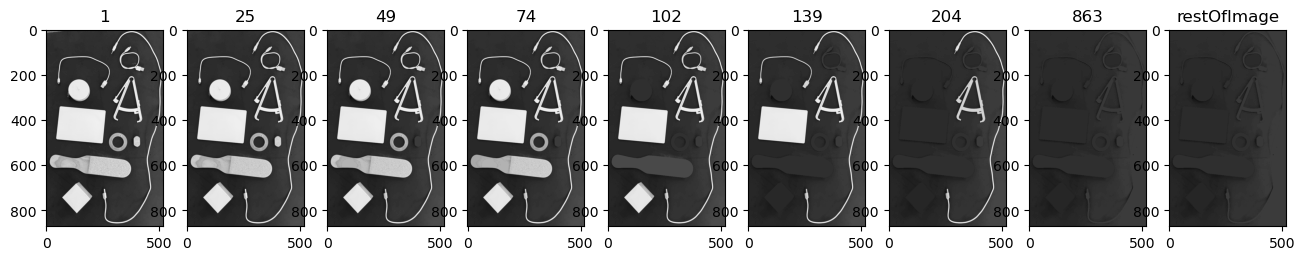

In [12]:
i = 0
for threshold in thrs:
    i += 1
    plt.subplot(1,len(thrs)+1, i)
    primitiva = primitives.getPrimitive(threshold) 
    plt.imshow(primitiva.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
    plt.title(str(int(threshold)))

rest = primitives.restOfImage
plt.subplot(1,len(thrs)+1, len(thrs)+1)
plt.imshow(rest.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('restOfImage')

Text(0.5, 1.0, 'residual filter (sem rest)')

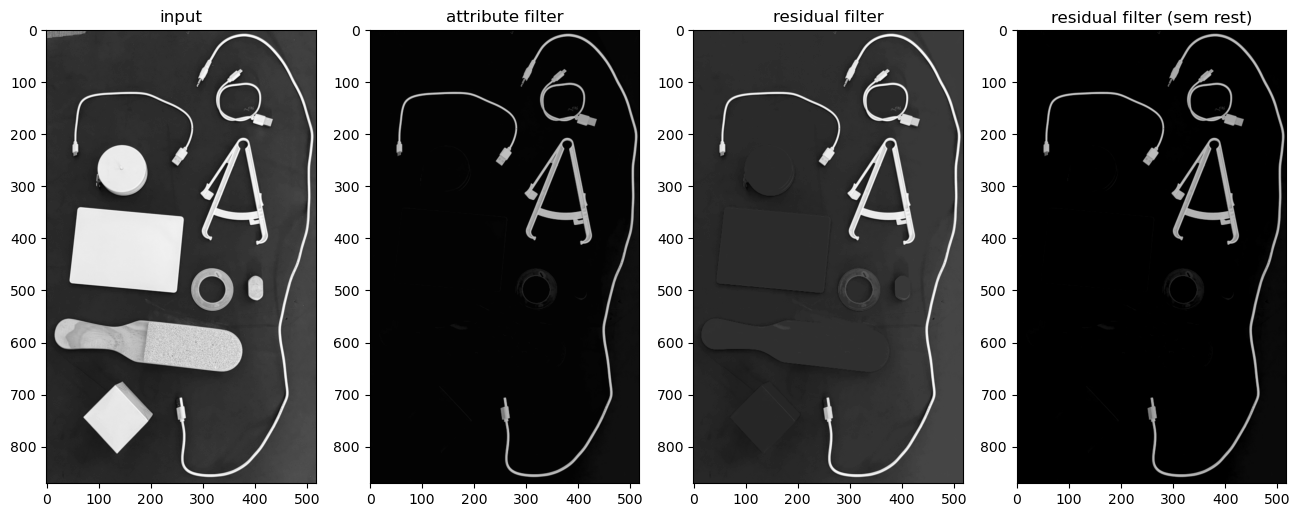

In [14]:
attribute = attrs[:,dic['HU_MOMENT_1_INERTIA']]
threshold = 0.3

filter = mmcfilters.AttributeFilters(tree)
imgAttrFilter = filter.filteringSubtractiveRule(attribute > threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgResFilter = rtree.filtering(attribute > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter')

plt.subplot(1,4, 3)
plt.imshow(imgResFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter')

plt.subplot(1,4, 4)
plt.imshow((imgResFilter - rest).reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter (sem rest)')

#np.sum(imgAttrFilter - imgResFilter)

Text(0.5, 1.0, 'filter')

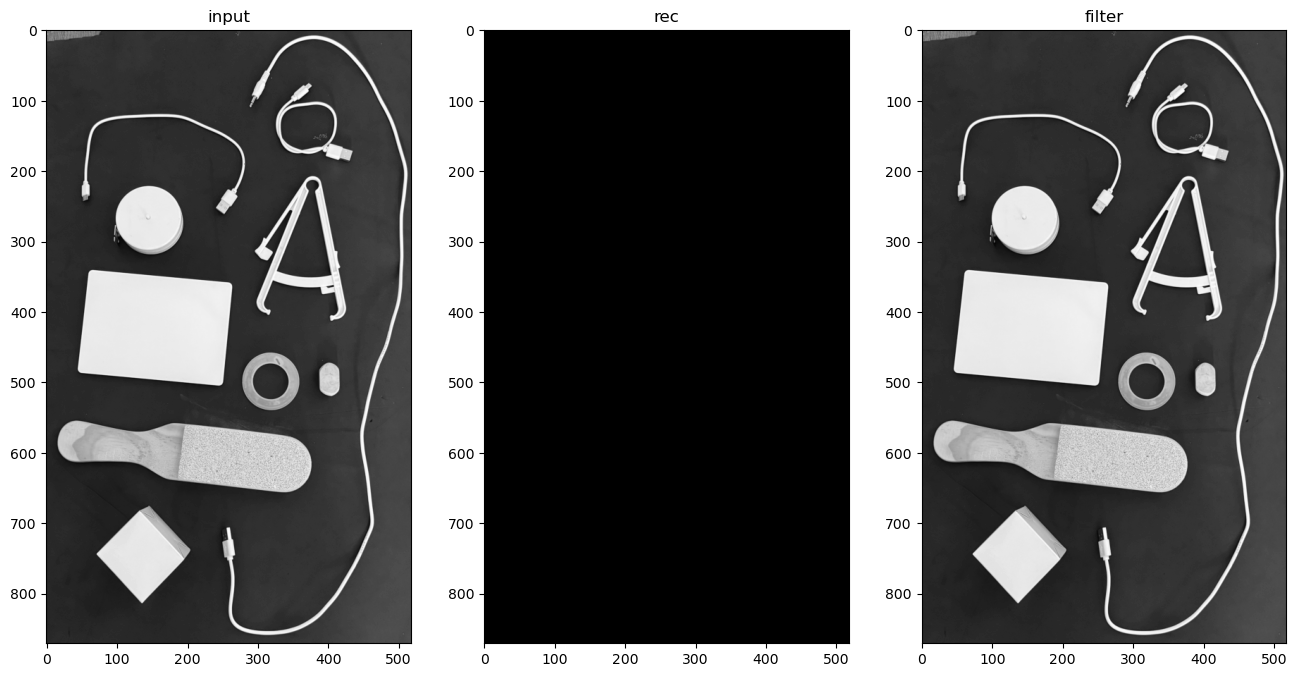

In [16]:
rtree = mmcfilters.ResidualTree(primitives)
imgrec = rtree.reconstruction() 
imgfilter = rtree.filtering(attr > 500)

plt.subplot(1,3, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,3, 2)
plt.imshow(imgrec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('rec')

plt.subplot(1,3, 3)
plt.imshow(imgfilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('filter')


#np.sum(imgInput.ravel() - imgrec)

Text(0.5, 1.0, 'associated')

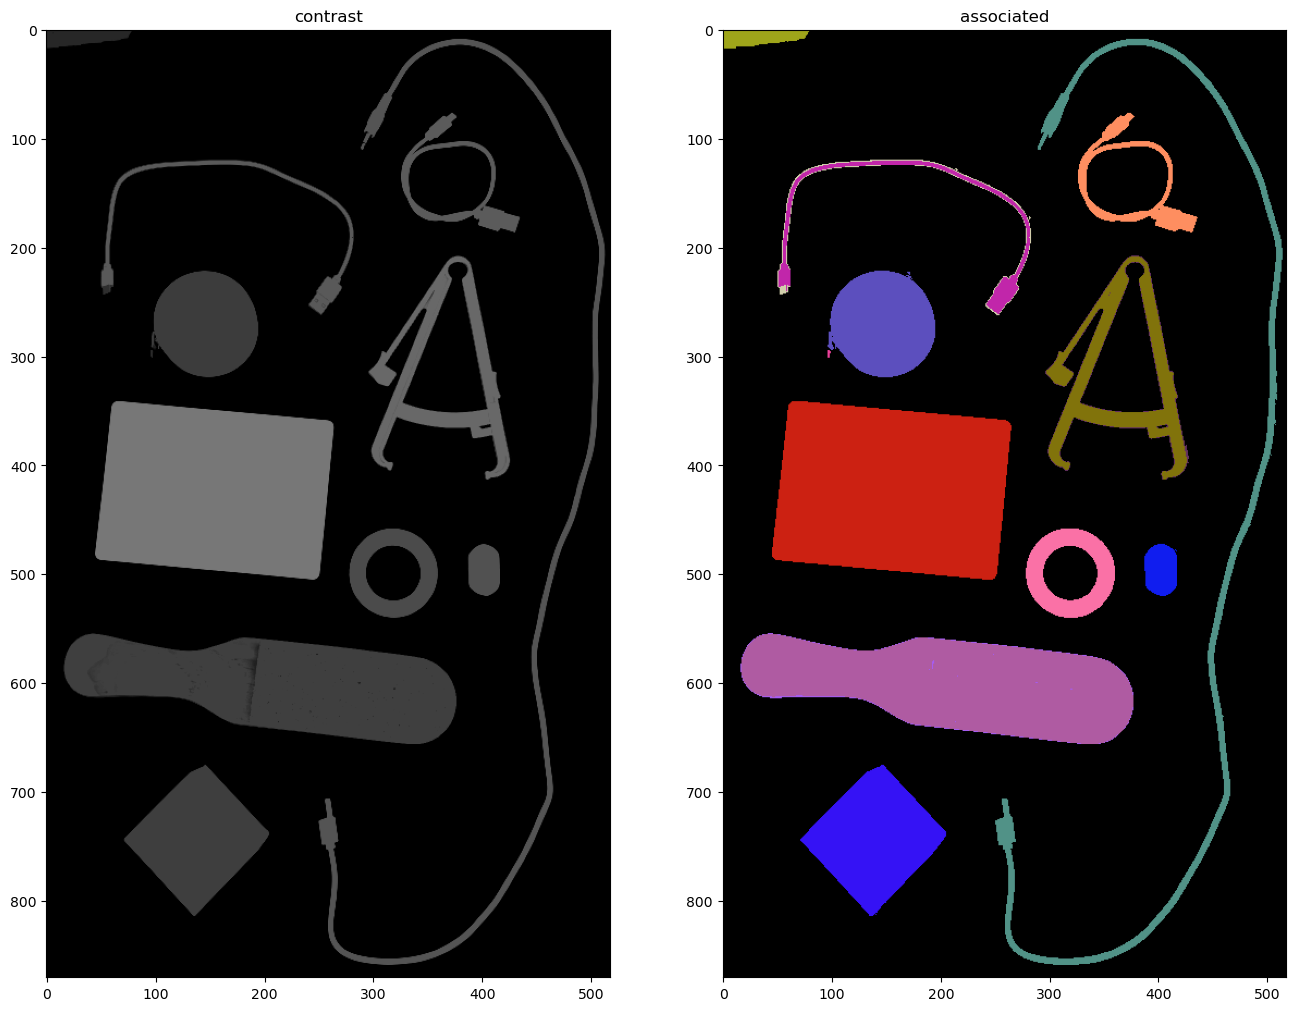

In [18]:
rtree.computerMaximumResidues()
imgContrast_rt = rtree.getMaxConstrastImage()
imgAssociatedColored_rt = rtree.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(imgContrast_rt.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(imgAssociatedColored_rt.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

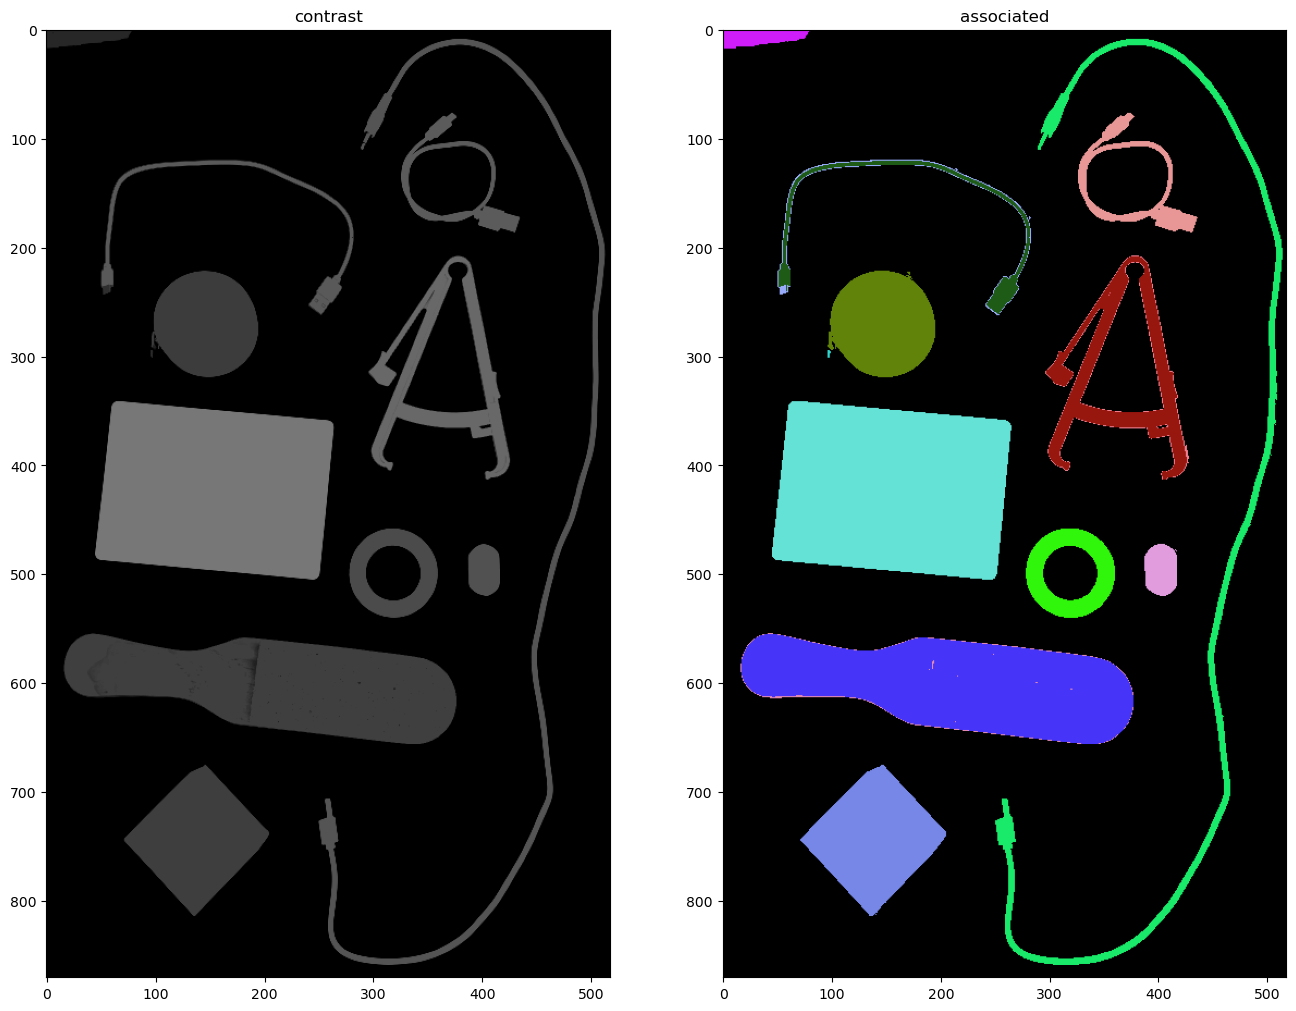

In [20]:
uao = mmcfilters.UltimateAttributeOpening(tree, attr)

uao.executeWithMSER( num_rows, deltaMSER )
imgAssociated = uao.getAssociatedColoredImage()
imgContrast = uao.getMaxConstrastImage()

#import random
#colors = [ [random.randint(0, 255) for _ in range(3)] for _ in range(0, np.max(imgAssociated)+1)]
#imgRGBContrast = [(0,0,0) if p == 0 else colors[p] for p in imgAssociated]

plt.subplot(1,2,1)
plt.imshow(imgContrast.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(np.array(imgAssociated).reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

In [22]:
np.sum(imgContrast_rt - imgContrast)

22014797

Text(0.5, 1.0, 'associated')

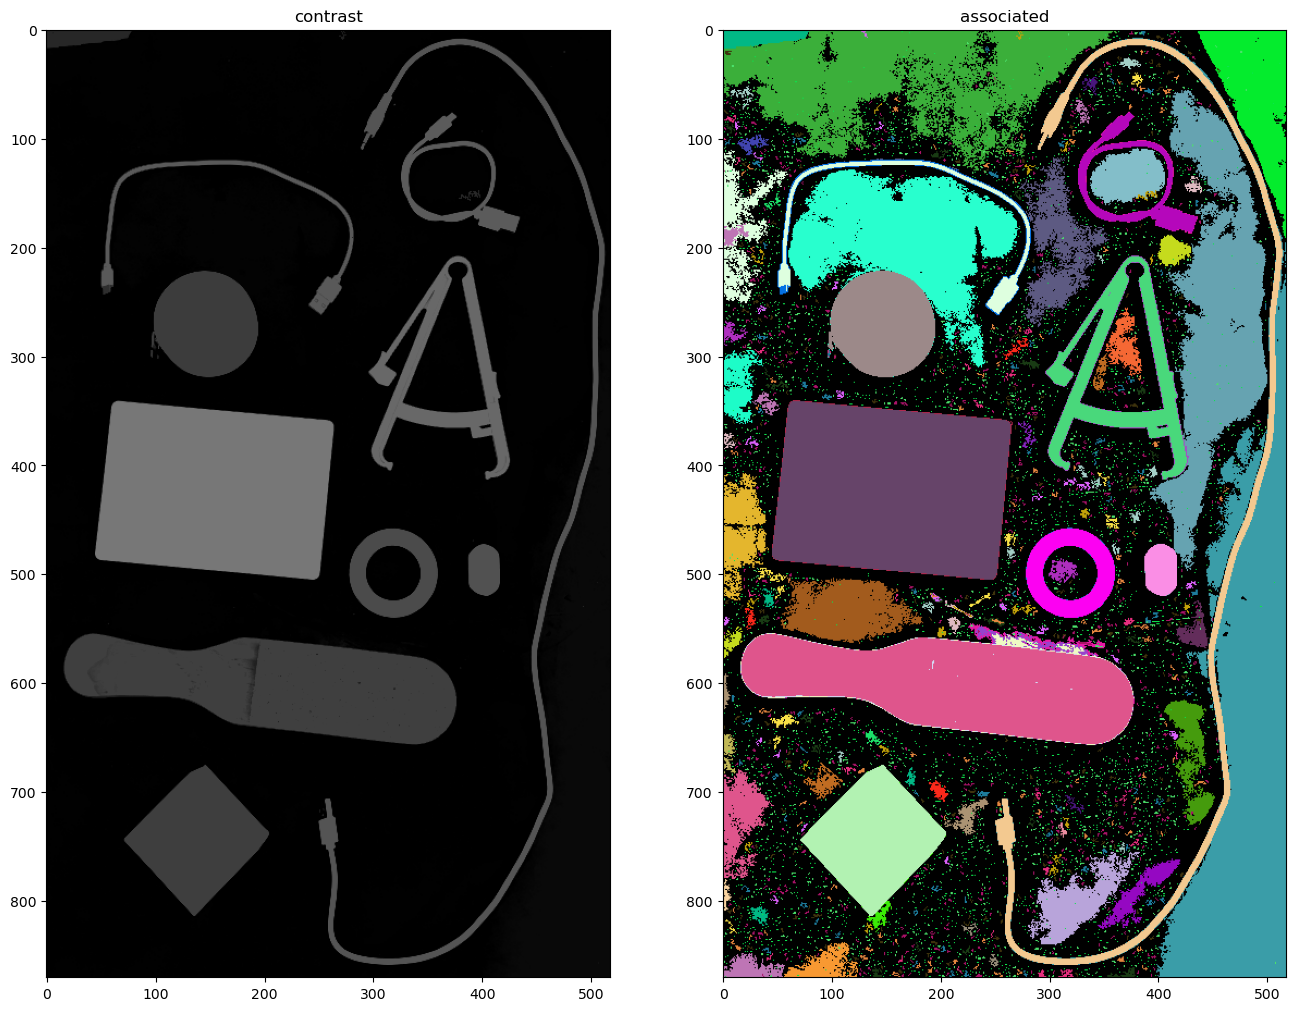

In [24]:
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
(num_rows, num_cols) = imgInput.shape
tree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, True, 1.5)
dic, attrs = mmcfilters.Attribute.computerBasicAttributes(tree)

uao = mmcfilters.UltimateAttributeOpening(tree, attrs[:,dic['BOX_HEIGHT']])
uao.execute( num_rows-1 )
imgContrast = uao.getMaxConstrastImage()
imgAssociatedColored = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(imgContrast.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(imgAssociatedColored.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Text(0.5, 1.0, 'associated')

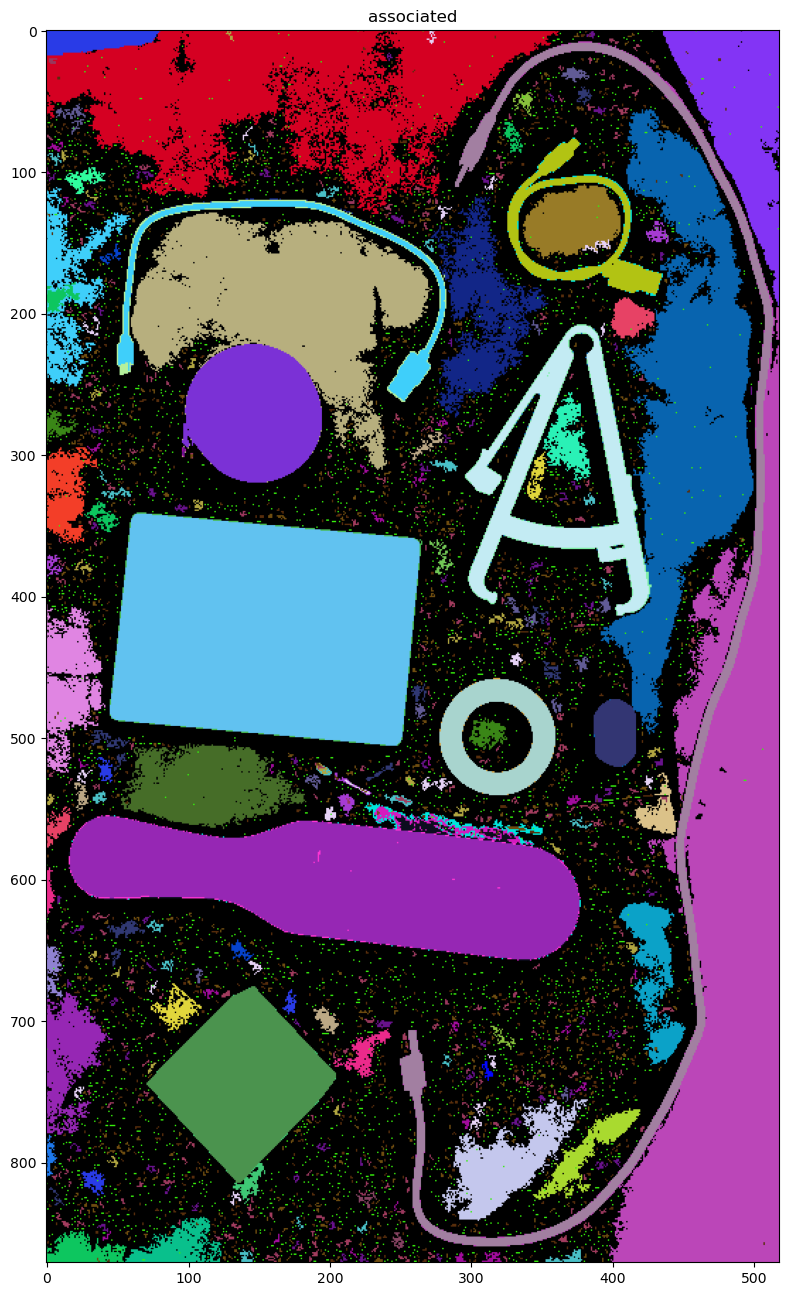

In [33]:
imgAssociated = uao.getAssociatedImage()

import random
colors = [ [random.randint(0, 255) for _ in range(3)] for _ in range(0, np.max(imgAssociated)+1)]
imgRGBContrast = [(0,0,0) if p == 0 else colors[p] for p in imgAssociated]

plt.imshow(np.array(imgRGBContrast).reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'associated')

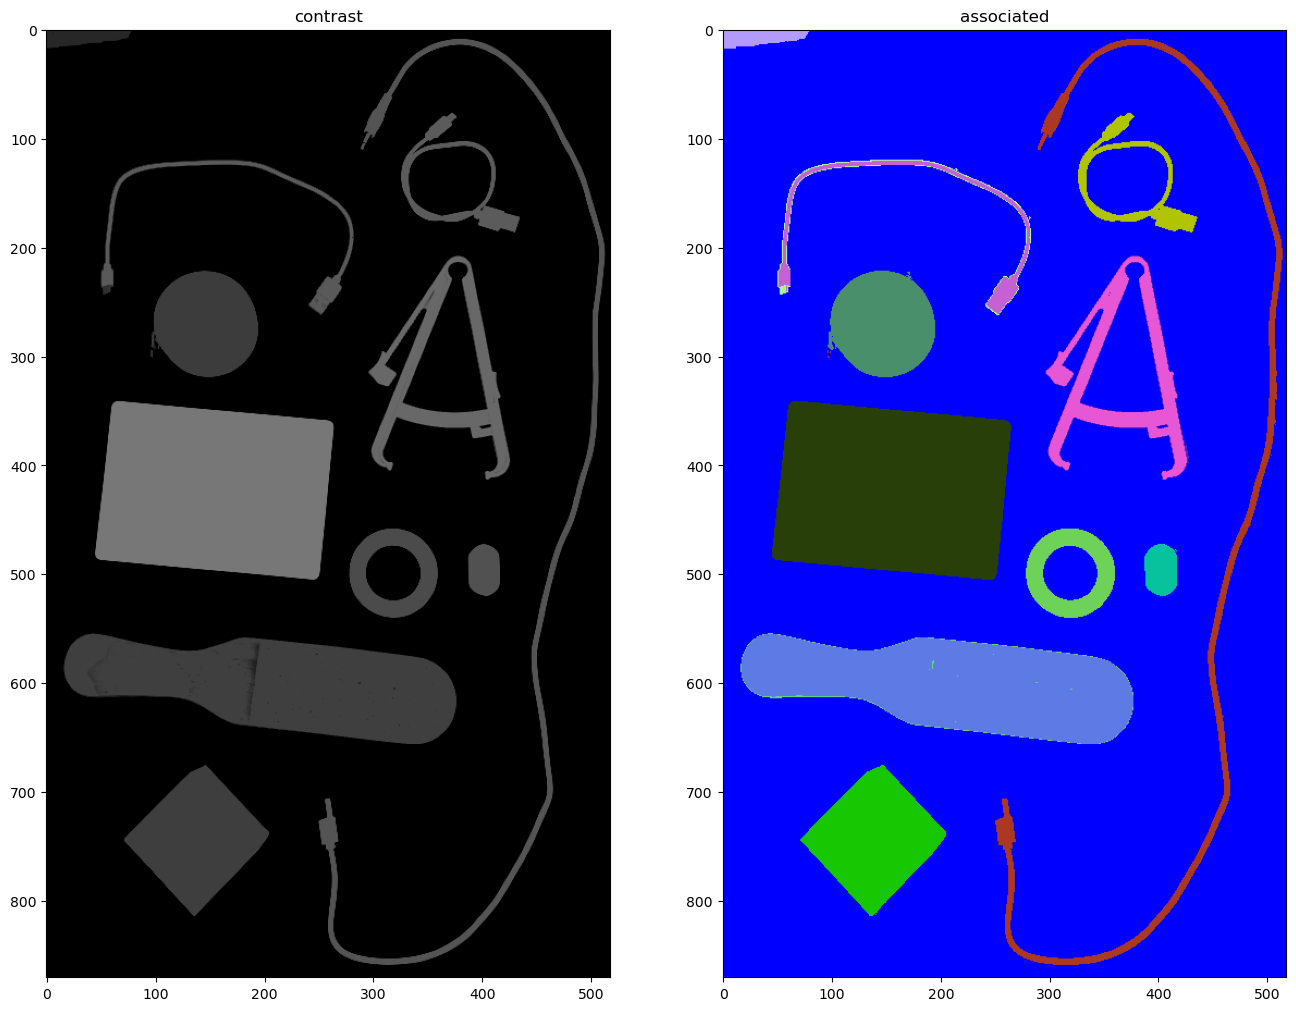

In [35]:
maxCriterion = num_rows
deltaMSER = 20

uao.executeWithMSER( int(maxCriterion), deltaMSER )
imgContrast = uao.getMaxConstrastImage()
imgAssociatedColored = uao.getAssociatedColoredImage()

plt.subplot(1,2,1)
plt.imshow(imgContrast.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('contrast')

plt.subplot(1,2,2)
plt.imshow(imgAssociatedColored.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
plt.title('associated')

In [37]:
np.min(imgAssociatedColored), np.max(imgAssociatedColored)

(0, 309375384)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


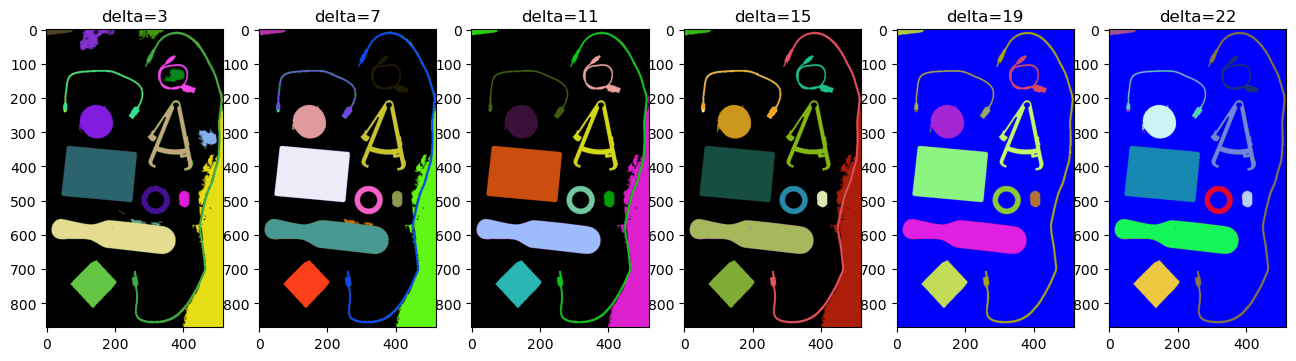

In [41]:
uao = mmcfilters.UltimateAttributeOpening(tree, attrs[:,dic['BOX_HEIGHT']])
maxCriterion = num_rows
line = 1
for i in range(1, 6+1):
    deltaMSER = int(i*3.8)
    uao.executeWithMSER( int(maxCriterion), deltaMSER )
    imgAssociatedColored = uao.getAssociatedColoredImage()
        
    plt.subplot(line,6, i)
    plt.imshow(imgAssociatedColored.reshape(num_rows, num_cols, 3), vmax=255, vmin=0)
    plt.title('delta=' + str(deltaMSER))